# Verification of simulation subpackage: Class to compute parameter limits (QualityRequirements)

In [1]:
# Import necessary libraries
from metpyx.sim import QualitySensitivity
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings

What the class should do:
- Compute the deviation in mean air-kerma-to-dose conversion coefficient for the deviations provided
- Check linearity of the deviation in mean conversion coefficient with respect to the deviation in tube voltage
- Linear fit of the deviation in mean conversion coefficient vs deviation in tube voltage
- Calculate the tube voltage deviation limits for a given deviation in mean conversion coefficient (e.g., 2%)

Reference case for verification:
- N60 radiation quality.
- Anode angle of 20º.
- H*(10) operational quantity at 0º irradiation angle.
- mass energy transfer coefficients for air from PENELOPE 2018.
- air kerma to dose conversion coefficients from CMI 2025.
- measurement distance at 1 m.
- air thickness equal to distance.
- Deviation of (-5%, 0%, +5%) in tube voltage

## Reference case: Calculation using the QualitySensitivity class

In [2]:
# Define tube voltage deviations in percentage
tube_voltage_deviations = [-5, 0, 5]

In [3]:
# Compute the deviation in mean air-kerma-to-dose conversion coefficient for the deviations provided
hk_mean_deviations = []
for dev in tube_voltage_deviations:
    q = QualitySensitivity("N60", 'tube_voltage', dev, th=20)
    hk_mean_deviations.append(q.get_hk_mean_dev('h_star_10', 0)[2])

/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:103: UserWarning: Zeros found in h_k values; removed for interpolation.
  warnings.warn("Zeros found in h_k values; removed for interpolation.")
/home/u6406/PycharmProjects/metpyx/src/metpyx/sim/spectrum.py:120: UserWarning: NaN values found in interpolated h_k.
  warnings.warn("NaN values found in interpolated h_k.")


In [4]:
# Linear fit of the deviation in mean conversion coefficient vs deviation in tube voltage

# Define the independent and dependent variables
x = np.asarray(tube_voltage_deviations)
y = np.asarray(hk_mean_deviations)

# Perform linear regression
X = sm.add_constant(x) # adds intercept term
model = sm.OLS(y, X) # ordinary least squares regression
res = model.fit() # fit the model

# Extract parameters, standard errors, and confidence intervals
intercept, slope = res.params # intercept is the constant term, slope is the coefficient for x
intercept_se, slope_se = res.bse # standard errors of the parameters
intercept_ci, slope_ci = res.conf_int(alpha=0.05) # 95% confidence intervals for the parameters
r_squared = res.rsquared # R-squared value
intercept_p_values, slope_p_values = res.pvalues # p-values for the parameters

# Print results
print(f"y = {slope:.6g} x + {intercept:.6g}")
print(f"Slope = {slope:.6g} ± {slope_se:.6g} ({slope_se/slope*100}%) (1σ)")
print(f"Intercept = {intercept:.6g} ± {intercept_se:.6g} ({intercept_se/intercept*100}%) (1σ)")
print(f"95% CI for slope = [{slope_ci[0]:.6g}, {slope_ci[1]:.6g}]")
print(f"95% CI for intercept = [{intercept_ci[0]:.6g}, {intercept_ci[1]:.6g}]")
print(f"Slope p-value = {slope_p_values:.4g}, intercept p-value = {intercept_p_values:.4g}")
print(f"R² = {r_squared:.4f}")

y = 0.324963 x + -0.0779649
Slope = 0.324963 ± 0.0135039 (4.155527491739227%) (1σ)
Intercept = -0.0779649 ± 0.0551295 (-70.71067811865474%) (1σ)
95% CI for slope = [0.153379, 0.496546]
95% CI for intercept = [-0.778451, 0.622522]
Slope p-value = 0.02644, intercept p-value = 0.3918
R² = 0.9983


In [5]:
# Simple decision rule for linearity: slope p-value < 0.05 and R² > 0.7

# Why only the slope p-value? Because we are interested in whether the slope is significantly different from zero, which indicates a linear relationship between the independent and dependent variables. The intercept p-value is less relevant for assessing linearity in this context, as it does not directly inform us about the relationship between x and y.
# Why slope p-value < 0.05? Because it indicates that there is a statistically significant linear relationship between the tube voltage deviation and the mean conversion coefficient deviation. If the slope p-value is greater than 0.05, we would fail to reject the null hypothesis that the slope is zero, suggesting that there may not be a linear relationship.
# What is the slope p-value? It is the probability of observing a slope as extreme as the one calculated from the data, assuming that the true slope is zero (no relationship). A low p-value indicates that such an extreme slope would be unlikely if there were no relationship, thus providing evidence for a linear relationship.
# What does a slope p-value < 0.05 mean? It means that there is less than a 5% chance of observing the calculated slope (or one more extreme) if the true slope were zero. This is commonly used as a threshold for statistical significance, suggesting that we have evidence to reject the null hypothesis of no relationship and accept the alternative hypothesis of a linear relationship.

# Why we check R²? Because it gives us an indication of how well the linear model explains the variability in the data. A high R² value (close to 1) suggests that the model fits the data well, while a low R² value indicates that the model does not capture much of the variability, which may suggest that a linear model is not appropriate.
# What does R² represent? It represents the proportion of the variance in the dependent variable (mean conversion coefficient deviation) that is predictable from the independent variable (tube voltage deviation). An R² of 0.7 means that 70% of the variance in the dependent variable can be explained by the linear model, which is generally considered a good fit.
# Which are good thresholds for R²? There is no strict threshold for R², as it can depend on the context and the field of study. However, a common rule of thumb is that an R² value above 0.7 indicates a strong linear relationship, while values below 0.3 may indicate a weak relationship. Values between 0.3 and 0.7 are often considered moderate.
# What other thresholds could be used for R²? Depending on the context, you might choose a more lenient threshold (e.g., 0.5) if you are working with complex data where a perfect linear fit is unlikely, or a more stringent threshold (e.g., 0.9) if you require a very strong linear relationship for your analysis.

# Evaluate linearity based on the decision rule
accept_linear = (slope_p_values < 0.05) and (r_squared > 0.7)

# Print the decision and criteria
print("Linear model plausible:", accept_linear)
print("Linearity criteria: slope p-value < 0.05 and R² > 0.7")

# Warning about small sample size
if len(y) and len(x) <= 3:
    print("Note: With only 3 data points, statistical tests may not be reliable. Consider this when interpreting results.")

Linear model plausible: True
Linearity criteria: slope p-value < 0.05 and R² > 0.7
Note: With only 3 data points, statistical tests may not be reliable. Consider this when interpreting results.


In [6]:
# Simple decision rule to check that the intercept is not significantly different from zero
# Statistically: intercept p-value > 0.05, and that the confidence interval for the intercept includes zero.
# Practically: relative difference below 1%.

# Statistical test: intercept p-value > 0.05 and confidence interval includes zero
statistical = (intercept_p_values > 0.05) and (intercept_ci[0] < 0 < intercept_ci[1])

# Practical test: check that the fitted intercept is negligibly small in absolute terms
# We use an absolute tolerance (atol) expressed in the same units as `intercept`.
# In this notebook `intercept` and `hk_mean_deviations` are expressed in percent (percentage points),
# so `atol = 1` means "allow the intercept to differ from zero by up to 1 percentage point"
# (i.e. intercept in the interval [-1, +1]).
# This is an absolute check (not relative): np.isclose(intercept, 0, atol=atol) tests
# whether abs(intercept - 0) <= atol.
atol = 1
# Use np.isclose to check if the intercept is close to zero within the absolute tolerance
practical = np.isclose(intercept, 0, atol=atol)

# Accept that the intercept is not significantly different from zero if both statistical and practical criteria are met
accept_intercept_zero = statistical and practical

# Print the decision and criteria
print("Intercept not significantly different from zero:", accept_intercept_zero)
print("Intercept criteria:")
print("Statistical: intercept p-value > 0.05 and confidence interval includes zero")
print("Practical: absolute difference below 1 percentage point")

Intercept not significantly different from zero: True
Intercept criteria:
Statistical: intercept p-value > 0.05 and confidence interval includes zero
Practical: absolute difference below 1 percentage point


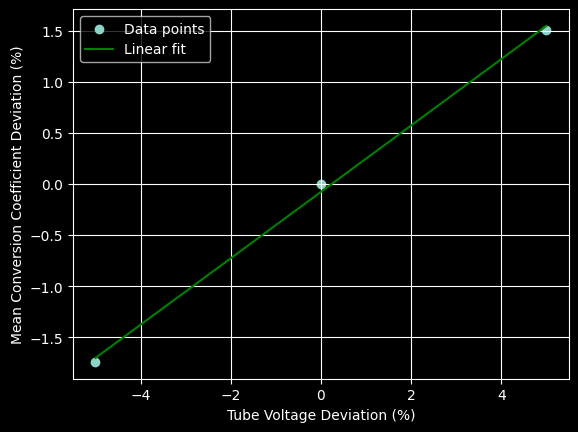

In [7]:
# Plotting the data points and the linear fit
xs = np.linspace(x.min(), x.max(), 100)
ys = intercept + slope * xs

plt.figure()
plt.scatter(x, y, label='Data points')
plt.plot(xs, ys, color="green", label='Linear fit')
plt.xlabel('Tube Voltage Deviation (%)')
plt.ylabel('Mean Conversion Coefficient Deviation (%)')
plt.legend()
plt.grid()
plt.show()

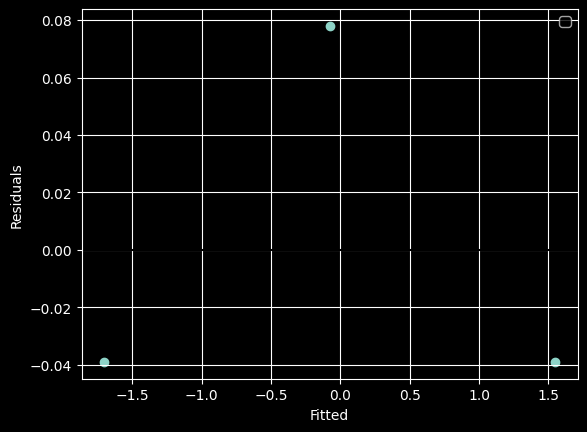

In [8]:
# Plotting the residuals of the linear fit

# What should we look for in the residuals plot? We should look for randomness in the distribution of residuals around zero, which would indicate that the linear model is appropriate. If we see patterns (e.g., a funnel shape, curvature, or systematic deviations), it may suggest that the linear model is not a good fit for the data.

fitted = res.fittedvalues
resid = res.resid

plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0, color="k")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.legend()
plt.grid()
plt.show()

In [9]:
# Calculate the tube voltage deviation limits for a given deviation in mean conversion coefficient (e.g., 2%)

# Define target deviation in mean conversion coefficient (percentage)
target_deviation = 2

# Use the linear fit to calculate the tube voltage deviation that corresponds to the target deviation in mean conversion coefficient
tube_voltage_deviation_limit = (target_deviation - intercept) / slope

# Propagate the uncertainty in the slope and intercept to calculate the uncertainty in the tube voltage deviation limit

# We can use the delta method for error propagation, which gives us the variance of a function of random variables (in this case, the tube voltage deviation limit as a function of the slope and intercept).
# The formula for the variance of a function f(a, b) where a and b are random variables with variances var_a and var_b, and covariance cov_ab, is:
# var_f = (df/da)^2 * var_a + (df/db)^2 * var_b + 2 * (df/da) * (df/db) * cov_ab
# In our case, f(slope, intercept) = (target_deviation - intercept) / slope
# So we need to calculate the partial derivatives df/dslope and df/dintercept, and then use the variances of the slope and intercept (which are the squares of their standard errors) to calculate the variance of the tube voltage deviation limit.

# Calculate the partial derivatives
df_dslope = - (target_deviation - intercept) / slope**2
df_dintercept = -1 / slope

# Calculate the variances of the slope and intercept
var_slope = slope_se**2
var_intercept = intercept_se**2

# Assuming slope and intercept are independent, the covariance is zero
cov_slope_intercept = 0

# Calculate the variance of the tube voltage deviation limit
var_tube_voltage_deviation_limit = (df_dslope**2 * var_slope) + (df_dintercept**2 * var_intercept) + (2 * df_dslope * df_dintercept * cov_slope_intercept)
# Calculate the standard error of the tube voltage deviation limit
se_tube_voltage_deviation_limit = np.sqrt(var_tube_voltage_deviation_limit)

# Print the tube voltage deviation limit and its uncertainty
print(f"Tube voltage deviation limit for a {target_deviation}% deviation in mean conversion coefficient: ({tube_voltage_deviation_limit:.2f} +- {se_tube_voltage_deviation_limit:.2f}) %")

Tube voltage deviation limit for a 2% deviation in mean conversion coefficient: (6.39 +- 0.32) %


## Design the class QualityRequirements

I want to transform the code in the previous section into a class called QualityRequirements.

### Main goals of the class

The main goal of the class are:

1. Compute a linear model of the relationship between tube voltage deviation and mean conversion coefficient deviation.
2. Compute the tube voltage requirements (i.e. deviation limit) for a given deviation in mean conversion coefficient.

### About the instance creation

The user should be able to create an instance of the class by providing the necessary input data: radiation quality (e.g. "N60") and the parameter to evaluate (e.g. "tube_voltage").
As the evaluation is made on mean air kerma-to-dose conversion coefficient, the user should also provide the operational quantity (e.g. "h_star_10") and the irradiation angle (e.g. 0º).

Other parameters will have default values but may be set by the user:
- set of tube voltage deviations (e.g. 10 values between -10% and 10%),
- linear fit criteria (e.g. slope p-value < 0.05 and R² > 0.7),
- intercept criteria (e.g. intercept p-value > 0.05, and absolute difference below 1 percentage point),
- target deviation in mean conversion coefficient (e.g. 2%),

The class should also accept additional arguments to be passed to the QualitySensitivity class for the calculation of the mean conversion coefficient deviations.

### What the class should do:

To complete its main goals (fit the model and compute the requirement), the class should perform the following steps:

- Compute the deviation in mean air-kerma-to-dose conversion coefficient for a given set of tube voltage deviations provided in the instance creation
- Linear fit of the deviation in mean conversion coefficient vs deviation in tube voltage.
- Check the linearity of the relationship between tube voltage deviation and mean conversion coefficient deviation.
- Check that the intercept of the linear fit is not significantly different from zero.
- Calculate the tube voltage deviation limits for a given deviation in mean conversion coefficient (e.g., 2%).

Additionally, the class should:

- The class should warn about the limitations of the analysis: small sample size, potential non-linearity or intercept significantly different from zero.
- The class should have methods to perform these calculations (fit the model and compute the requirement).
- The class methods should return the results in a structured way (preferably in a new type ob object so that the inspection of the results is easy).
- The class should provide a method to visualize the data and the linear fit, as well as the residuals of the fit, to help users assess the quality of the fit and the validity of the assumptions made in the analysis.

### Class implementation

In [10]:
class QualityRequirements:
    """
    Compute linear relationship between a parameter deviation (e.g. tube voltage)
    and the mean air-kerma-to-dose conversion coefficient deviation, using
    metpyx.sim.QualitySensitivity for the underlying simulations.
    """

    def __init__(self, quality, parameter, quantity, angle, deviations = None, target = 2, r_squared = 0.7, p_value = 0.05, atol = 1.0, kwargs = None):
        # Probably rename arguments to be shorter (e.g. deviations, target, r_squared, p_value, atol)
        self.quality = quality
        self.parameter = parameter
        self.quantity = quantity
        self.angle = angle
        self.deviations = (np.asarray(deviations) if deviations is not None else np.linspace(0, 10, 11))
        self.target = target
        self.r_squared = r_squared
        self.p_value = p_value
        self.atol = atol
        self.kwargs = kwargs if kwargs is not None else {}
        # Storage attributes for results
        self.mean_hk = None
        self.x = None
        self.y = None
        self.sm_results = None

    def compute_deviations(self):
        """Call QualitySensitivity for each deviation and build y (mean conversion deviations)."""
        res = {'nominal': [], 'deviated': [], 'deviation': []}
        vals = []
        for d in self.deviations:
            q = QualitySensitivity(self.quality, self.parameter, d, **self.kwargs)
            out = q.get_hk_mean_dev(self.quantity, self.angle)
            v = out[-1]
            vals.append(v)
            res['nominal'].append(out[0])
            res['deviated'].append(out[1])
            res['deviation'].append(out[2])
        self.mean_hk = res
        self.x = np.asarray(self.deviations, dtype=float)
        self.y = np.asarray(res['deviation'], dtype=float)
        if self.x.size <= 3:
            warnings.warn("Small sample size (<=3). Statistical tests and confidence intervals may be unreliable.")
        return self.x, self.y

## Reference case: Calculation using the QualityRequirements class

In [11]:
qr = QualityRequirements("N60", 'tube_voltage', 'h_star_10', 0, deviations=[-5, 0, 5], kwargs={'th': 20})
# qr.compute_deviations()
# qr.fit_model()
# qr.check_linearity()
# qr.check_intercept()
# qr.compute_requirement()

## Reference case: Assertions

In [18]:
# Constructor
qr = QualityRequirements("N60", 'tube_voltage', 'h_star_10', 0, deviations=[-5, 0, 5], kwargs={'th': 20})

assert qr.quality=="N60"
assert qr.parameter=='tube_voltage'
assert qr.quantity=='h_star_10'
assert qr.angle==0
assert list(qr.deviations) == [-5, 0, 5]
assert qr.target == 2
assert qr.r_squared == 0.7
assert qr.p_value == 0.05
assert qr.atol == 1.0
assert qr.kwargs == {'th': 20}

In [19]:
# Compute deviations
qr = QualityRequirements("N60", 'tube_voltage', 'h_star_10', 0, deviations=[-5, 0, 5], kwargs={'th': 20})
qr.compute_deviations()

assert list(qr.x) == [-5, 0, 5]
assert list(qr.y) == [-1.7417605772415357, 0.0, 1.5078659536864027]
assert qr.mean_hk['nominal'] == [1.5652667635344535, 1.5652667635344535, 1.5652667635344535]
assert qr.mean_hk['deviated'] == [1.5380035641185459, 1.5652667635344535, 1.5888688881461586]
assert qr.mean_hk['deviation'] == [-1.7417605772415357, 0.0, 1.5078659536864027]

/tmp/ipykernel_20042/2235161949.py:43: UserWarning: Small sample size (<=3). Statistical tests and confidence intervals may be unreliable.
  warnings.warn("Small sample size (<=3). Statistical tests and confidence intervals may be unreliable.")


In [20]:
print("All assertions passed!")

All assertions passed!
